# Домашнє завдання: Візуалізація даних з Matplotlib

## Опис завдання
У цьому домашньому завданні ви продовжите працювати з датасетом про оренду велосипедів `yulu_rental.csv`, але тепер будете використовувати бібліотеку Matplotlib для створення більш складних та налаштованих візуалізацій.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---


🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Завантаження даних
df = pd.read_csv('drive/MyDrive/Python/Data/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додаткові колонки
df['month'] = df.index.month
df['hour'] = df.index.hour
df['weekday'] = df.index.day_name()
df['weekday_num'] = df.index.weekday
df['week'] = df.index.isocalendar().week
df['year'] = df.index.year
df['day'] = df.index.day

In [3]:
df.head(5)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,month,hour,weekday,weekday_num,week,year,day
datetime,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,1,0,Saturday,5,52,2011,1
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1,1,Saturday,5,52,2011,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,1,2,Saturday,5,52,2011,1
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,1,3,Saturday,5,52,2011,1
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,1,4,Saturday,5,52,2011,1


## Завдання 1: Порівняння Pandas vs Matplotlib

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно впродовж всього періоду в даних двома способами:
1. Використовуючи Pandas (DataFrame.plot())
2. Використовуючи Matplotlib безпосередньо

В обох методах додайте маркери-кружечки. Можна також задати свій відмінний від стандартного колір.

Підказка: отримати потрібний формат даних найзручніше з методом датафрейму `resample`.

**Опишіть свої спостереження:** чим відрізняються 2 побудованих графіки? Який вам більше подобається?

In [20]:
# Середня кількість орендованих велосипедів по місяцях за годину
monthly_avg_count = df['count'].resample('ME').mean()

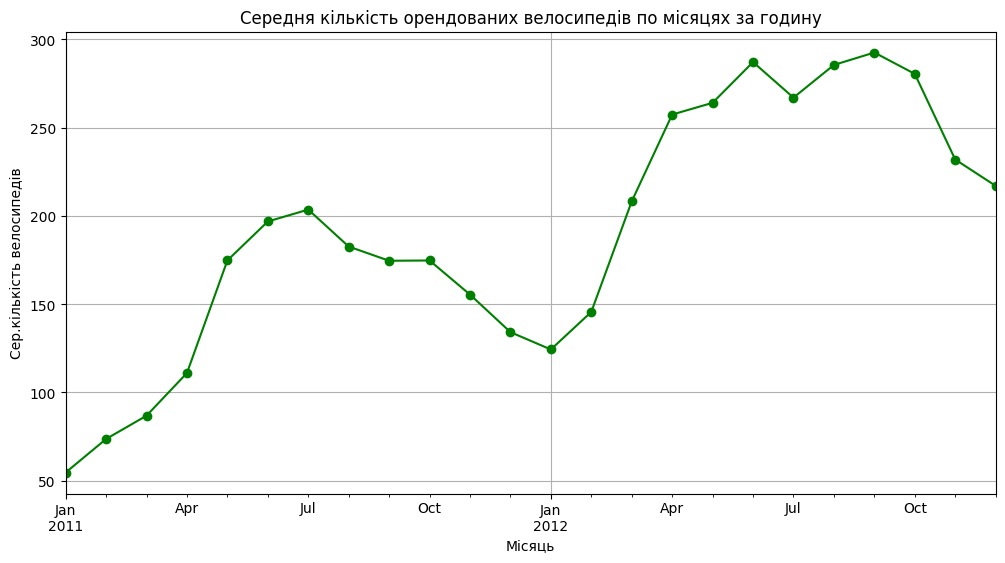

In [21]:
# Лінійний графік використовуючи Pandas
monthly_avg_count.plot(
    kind='line',
    marker='o',
    figsize=(12, 6),
    color='green',
    title='Середня кількість орендованих велосипедів по місяцях за годину',
    xlabel='Місяць',
    ylabel='Сер.кількість велосипедів',
    grid=True
)
plt.show()

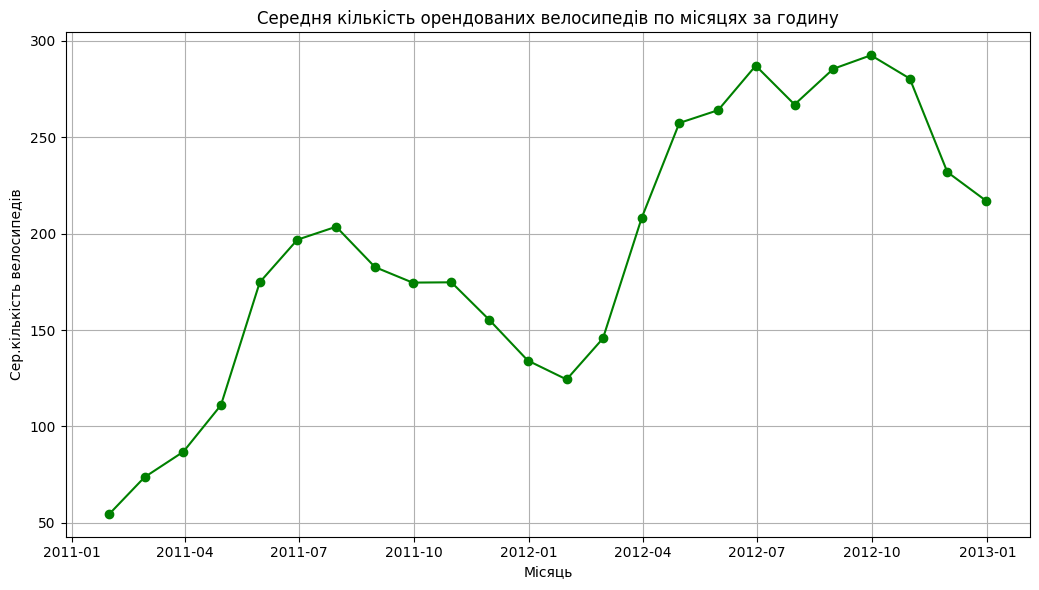

In [22]:
# Лінійний графік використовуючи Matplotlib
plt.figure(figsize=(10.5, 6))
plt.plot(monthly_avg_count, 'o-g')
plt.title('Середня кількість орендованих велосипедів по місяцях за годину')
plt.xlabel('Місяць')
plt.ylabel('Сер.кількість велосипедів')
plt.tight_layout()
plt.grid(True)

plt.show()

По моїм спостереженням графіки виглядають майже однаково, але мені візуально більше подобається графік через Matpoltlib, бо лінія починається з відcтупом від осі Y та надписи місяців на осі Х одразу йдуть з роками. Таке сприйняття мені краще.

## Завдання 2: Робота зі списками та numpy

**Завдання:**
Вам задані 3 списки:
1. Номер дня тижня.
2. Продажі в тиждень 1.
3. Продажі в тиждень 2.

Створіть графік, на якому лінійними графіками різних кольорів накладено продажі за обидва тижні.

Обовʼязково додайте назву графіку, підписи вісям ОХ, ОУ, назви кожного з рядів даних, легенду.

**Дайте відповіді на питання**
1. Судячи з графіку, в який тиждень продажі були стабільніше?
2. Чи можете ви підкріпити свій висновок обчисленнями? Якими саме? Можна (але не обовʼязково) навести ці обчислення.

In [7]:
# Дані у вигляді списків
days = [1, 2, 3, 4, 5, 6, 7] # 1 - це понеділок
sales_week1 = [1349,1562,1600,1606,1510,959,822]  # Продажі за тиждень1
sales_week2 = [1321,1263,1162,1406,1421,1248,1204]  # Продажі за тиждень1

In [8]:
days_names = ['Понеділок', 'Вівторок', 'Середа', 'Четвер', 'Пʼятниця', 'Субота', 'Неділя']

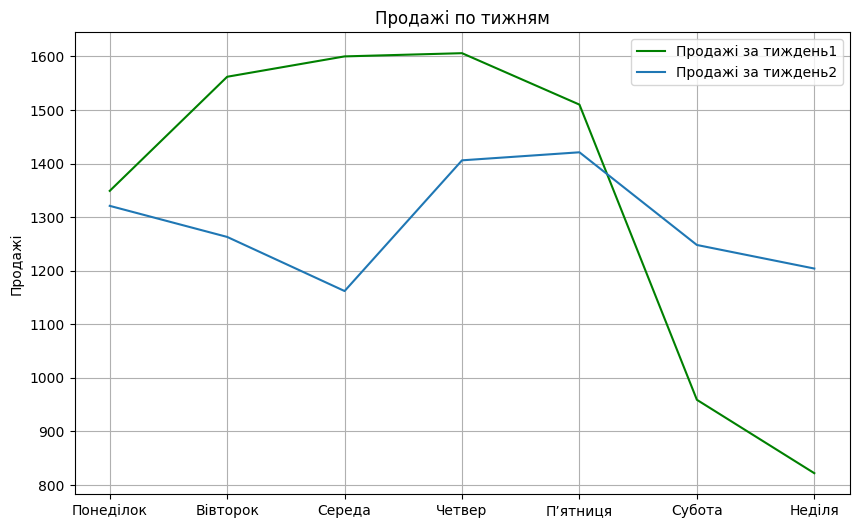

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(days_names, sales_week1, label='Продажі за тиждень1', color='green')
plt.plot(days_names, sales_week2, label='Продажі за тиждень2')
plt.title('Продажі по тижням')
plt.ylabel('Продажі')
plt.grid(True)
plt.legend()
plt.show()

**Відповіді на питання**

1. Судячи з графіку, в який тиждень продажі були стабільніше?

*Судячи з графіку більш стабільніші продажі були в другому тижні, бо між днями різниця в продажах коливалася без різких спадів та сплесків продажів. Натомість в перший тиждень було різке падіння продажівв суботу та неділю у порівнянні з будніми днями.*

2. Чи можете ви підкріпити свій висновок обчисленнями? Якими саме? Можна (але не обовʼязково) навести ці обчислення.

*На виявлення більш стабільного тижня краще розрахувати стандартне відхилення, який покаже наскільки сильно значення в наборі даних у середньому відхиляються від їхнього середнього значення.
З розрахунку статистичних даних видно, що стандартне відхилення другого тижня в 3 рази менше у порівнянні з першим тижнем, тобто в другому тижні продажі стабільніші.*

In [10]:
data = pd.DataFrame({
    'Тиждень 1': sales_week1,
    'Тиждень 2': sales_week2
})

In [11]:
data.describe()

,Тиждень 1,Тиждень 2
count,7.000000,7.000000
mean,1344.000000,1289.285714
std,324.035492,98.189806
min,822.000000,1162.000000
25%,1154.000000,1226.000000
50%,1510.000000,1263.000000
75%,1581.000000,1363.500000
max,1606.000000,1421.000000


## Завдання 3: Subplot - 2x2 сітка графіків

**Завдання:**
Створіть сітку 2x2 з чотирма різними графіками, використовуючи `plt.subplot()`:
1. Лінійний графік середньої температури помісячно.
2. Стовпчикова діаграма середньої годинної кількості оренд за кварталами.
3. Гістограма вологості за всіма погодинними вимірами.
4. Scatter plot температури vs кількості оренд.

Кожен підграфік має містити всі необхідні підписи. Дашборд має містити назву.

In [12]:
import matplotlib.pyplot as plt
import numpy as np

In [13]:
# Середня температура помісячно
monthly_avg_temp = df['temp'].resample('ME').mean()

In [14]:
# Середня кількість орендованих велосипедів по кварталам за годину
quarterly_avg_count = df.groupby('season')['count'].mean()

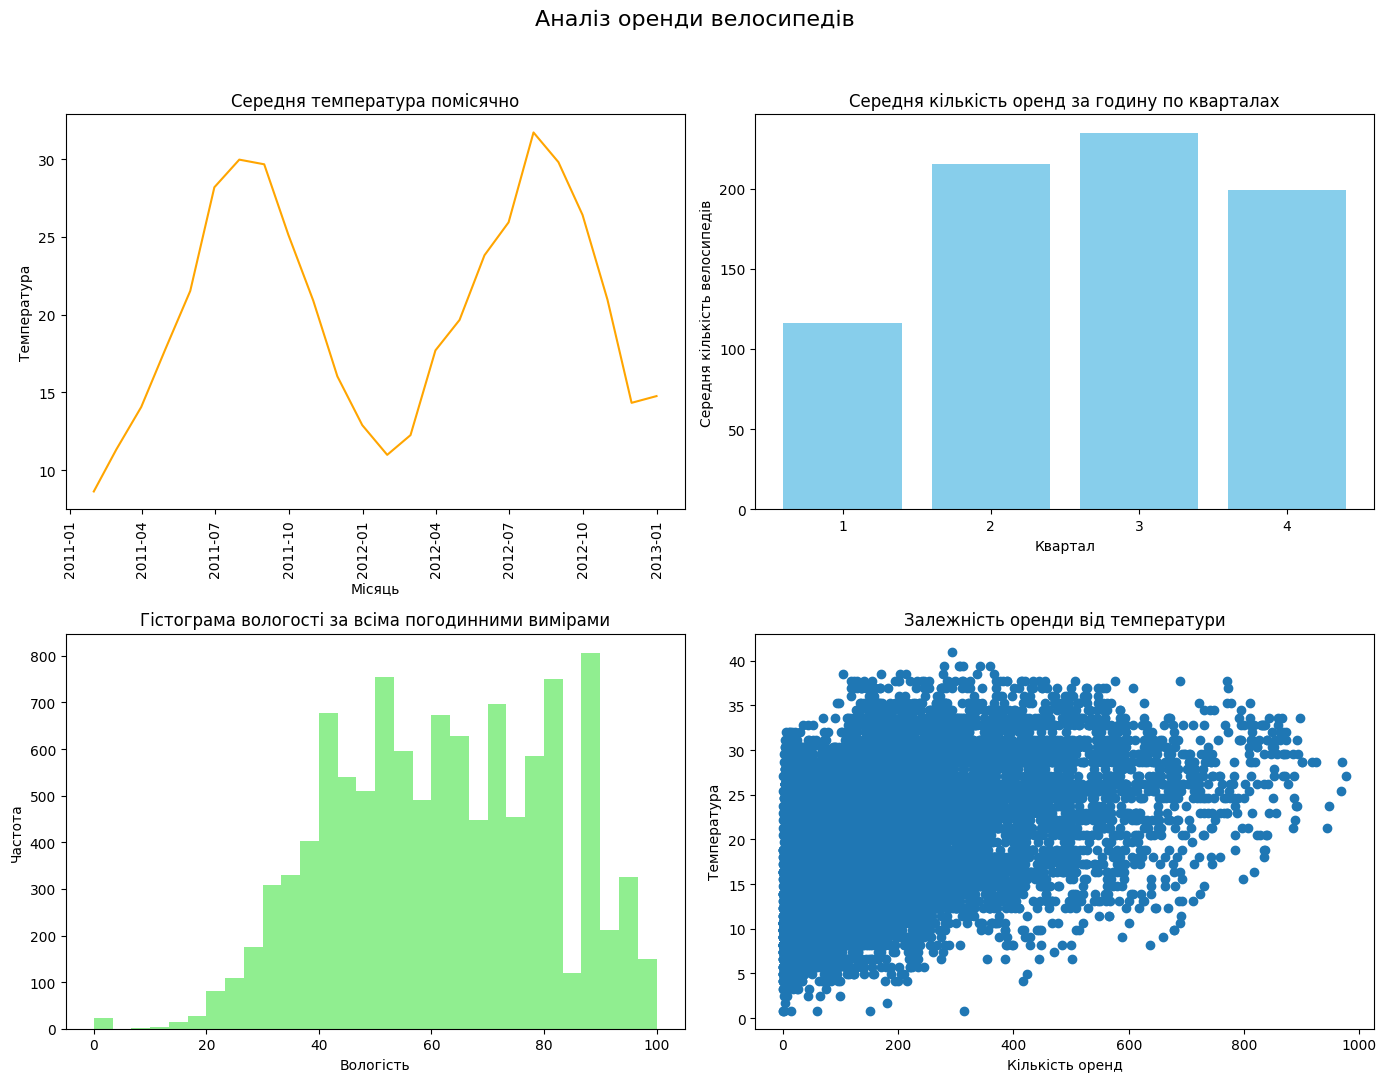

In [23]:
plt.figure(figsize=(14, 11))

# Лінійний графік
plt.subplot(2, 2, 1)
plt.plot(monthly_avg_temp, color='orange')
plt.title('Середня температура помісячно')
plt.xlabel('Місяць')
plt.ylabel('Температура')
plt.xticks(rotation=90)

# Стовпчиковий графік
plt.subplot(2, 2, 2)
plt.bar(quarterly_avg_count.index, quarterly_avg_count.values, color='skyblue')
plt.title('Середня кількість оренд за годину по кварталах')
plt.xlabel('Квартал')
plt.ylabel('Середня кількість велосипедів')
plt.xticks([1, 2, 3, 4], ['1', '2', '3', '4'])

# Гістограма
plt.subplot(2, 2, 3)
plt.hist(df['humidity'], bins=30, color='lightgreen')
plt.title('Гістограма вологості за всіма погодинними вимірами')
plt.xlabel('Вологість')
plt.ylabel('Частота')

# Scatter plot
plt.subplot(2, 2, 4)
plt.scatter(df['count'], df['temp'])
plt.title('Залежність оренди від температури')
plt.xlabel('Кількість оренд')
plt.ylabel('Температура')

# Загальний вигляд
plt.suptitle('Аналіз оренди велосипедів', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Завдання 4: Subplots - об'єктно-орієнтований підхід

**Завдання:**
Створіть той самий набір графіків, але використовуючи `fig, ax = plt.subplots()`.

**Дайте відповідь на питання своїми словами**
- Чим відрізняється підхід побудови кількох графіків на одній фігурі з `plt.subplots()` від `plt.subplot()`?

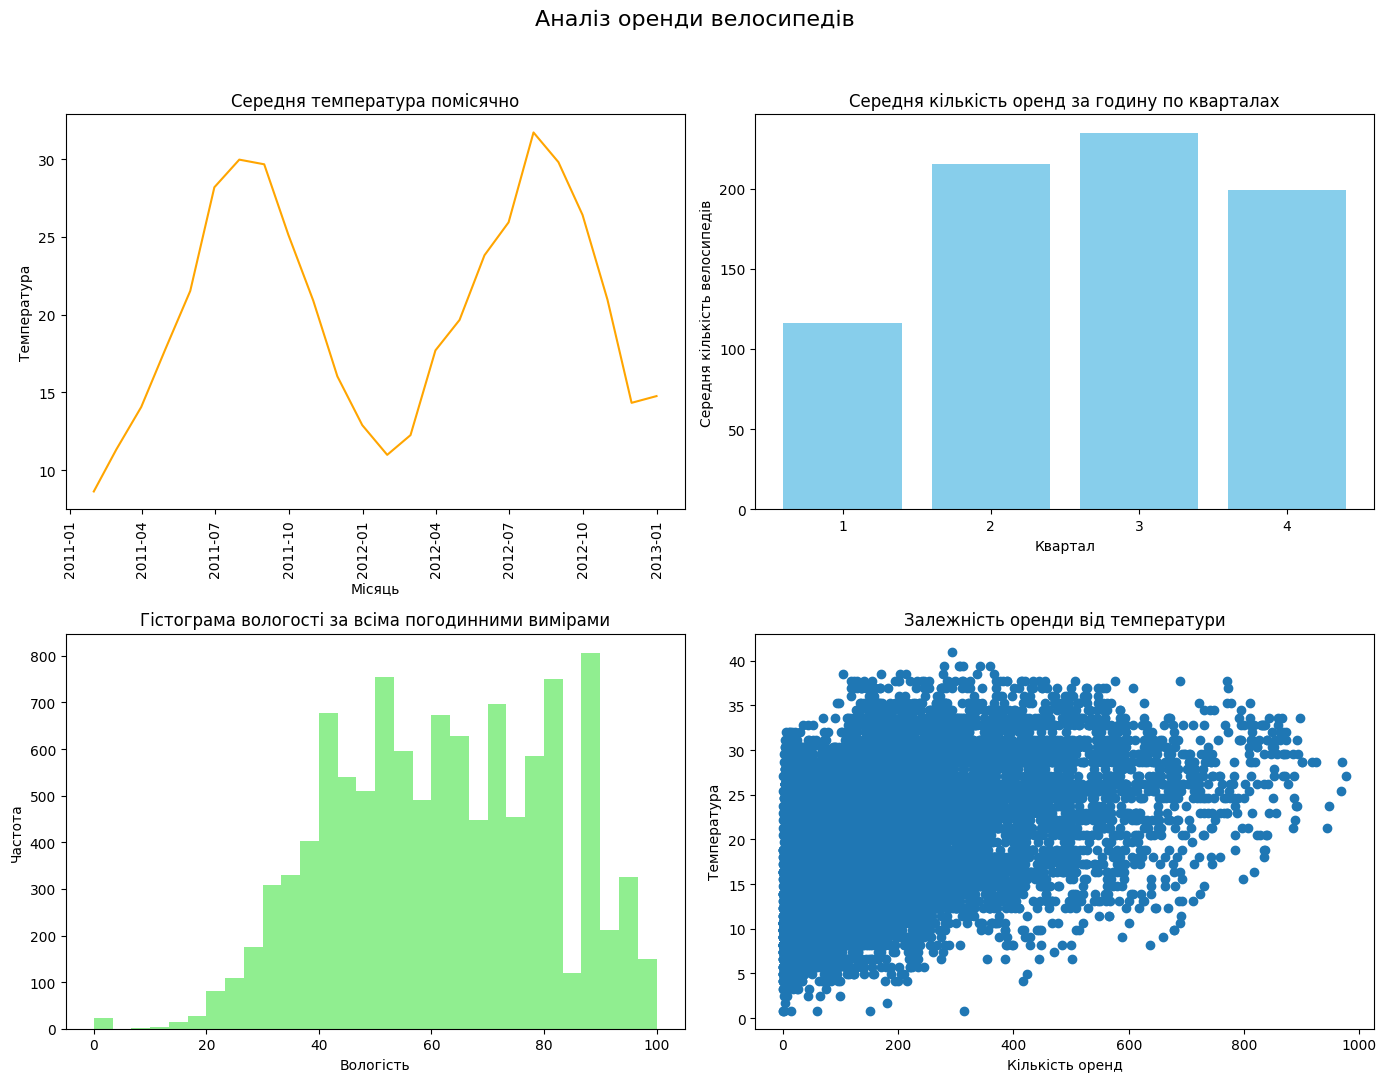

In [24]:
# Створюємо 2x2 сітку графіків
fig, ax = plt.subplots(2, 2, figsize=(14, 11))

# Лінійний графік
ax[0, 0].plot(monthly_avg_temp, color='orange')
ax[0, 0].set_title('Середня температура помісячно')
ax[0, 0].set_xlabel('Місяць')
ax[0, 0].set_ylabel('Температура')
ax[0, 0].tick_params(axis='x', rotation=90)

# Стовпчиковий графік
ax[0, 1].bar(quarterly_avg_count.index, quarterly_avg_count.values, color='skyblue')
ax[0, 1].set_title('Середня кількість оренд за годину по кварталах')
ax[0, 1].set_xlabel('Квартал')
ax[0, 1].set_ylabel('Середня кількість велосипедів')
ax[0, 1].set_xticks([1, 2, 3, 4])
ax[0, 1].set_xticklabels(['1', '2', '3', '4'])

# Гістограма
ax[1, 0].hist(df['humidity'], bins=30, color='lightgreen')
ax[1, 0].set_title('Гістограма вологості за всіма погодинними вимірами')
ax[1, 0].set_xlabel('Вологість')
ax[1, 0].set_ylabel('Частота')

# Scatter plot
ax[1, 1].scatter(df['count'], df['temp'])
ax[1, 1].set_title('Залежність оренди від температури')
ax[1, 1].set_xlabel('Кількість оренд')
ax[1, 1].set_ylabel('Температура')

# Загальний вигляд
fig.suptitle('Аналіз оренди велосипедів', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])


## (Опціонально) Завдання 5: Тонкі налаштування форматування графіка

**Завдання:**
Подібно до прикладу, наведеного в лекції, створіть професійно оформлений графік помісячної динаміки оренди з максимальною кількістю деталей та налаштувань. Ваш графік має включати:

**Обов'язкові елементи:**
1. **Три лінії:** середнє, максимум, мінімум за місяцями
2. **Різні стилі ліній:** суцільна, пунктирна, крапкова + різні маркери
3. **Заливка області** між мінімумом та максимумом
4. **Дві анотації:** для найвищого та найнижчого середнього значення
5. **Горизонтальна лінія** середнього за весь рік
6. **Двошарова сітка:** основна та допоміжна
7. **Стилізована легенда** з тінню
8. **Текстовий блок** зі статистикою в кутку графіка
9. **Професійне оформлення:** заголовки, підписи осей з жирним шрифтом

**Результат:** Графік повинен виглядати як готова ілюстрація для бізнес-звіту або наукової публікації.

Приклад очікуваного результату.
![](https://drive.google.com/uc?id=1YoJByivzlqncEF2zbWu3EhGSZ7XRme8T)


**Питання для інтерпретації:**
1. Яка перевага додавання анотацій на графік?
2. Для чого використовується fill_between()?
3. Як текстовий блок допомагає в інтерпретації даних?

In [28]:
import matplotlib.dates as mdates

In [30]:
# Розрахунок середнього, максимуму та мінімуму по місяцях
monthly_stats = df['count'].resample('ME').agg(['mean', 'max', 'min'])

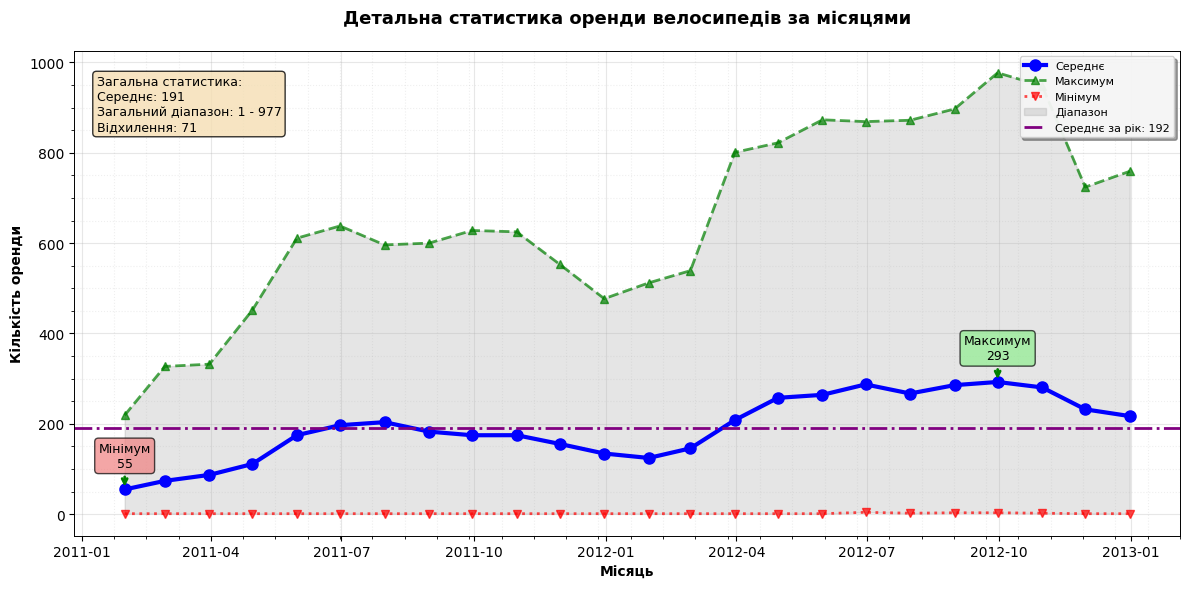

In [65]:
fig, ax = plt.subplots(figsize=(12, 6))

# Малюємо лінії з різними стилями
ax.plot(monthly_stats.index, monthly_stats['mean'], 'b-o', linewidth=3,
        label='Середнє', markersize=8)
ax.plot(monthly_stats.index, monthly_stats['max'], 'g--^', linewidth=2,
        label='Максимум', markersize=6, alpha=0.7)
ax.plot(monthly_stats.index, monthly_stats['min'], 'r:v', linewidth=2,
        label='Мінімум', markersize=6, alpha=0.7)

# Заливка між max та min (правильний синтаксис)
ax.fill_between(monthly_stats.index, monthly_stats['min'], monthly_stats['max'],
                alpha=0.2, color='gray', label='Діапазон')

# Додаємо анотації для максимального значення
max_idx = monthly_stats['mean'].idxmax()
max_val = monthly_stats['mean'].max()
ax.annotate(f'Максимум\n{max_val:.0f}',
            xy=(max_idx, max_val), xytext=(max_idx, max_val + 50),
            arrowprops=dict(arrowstyle='->', color='green', lw=2),
            fontsize=9, ha='center',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='lightgreen', alpha=0.7))

# Додаємо анотації для мінімального значення
min_idx = monthly_stats['mean'].idxmin()
min_val = monthly_stats['mean'].min()
ax.annotate(f'Мінімум\n{min_val:.0f}',
            xy=(min_idx, min_val), xytext=(min_idx, min_val + 50),
            arrowprops=dict(arrowstyle='->', color='green', lw=2),
            fontsize=9, ha='center',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='lightcoral', alpha=0.7))

# Налаштування осей
ax.set_xlabel('Місяць', fontsize=10, fontweight='bold')
ax.set_ylabel('Кількість оренди', fontsize=10, fontweight='bold')
ax.set_title('Детальна статистика оренди велосипедів за місяцями',
             fontsize=13, fontweight='bold', pad=20)

# Форматування дат на осі X
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))

# Додаємо сітку з різними стилями
ax.grid(True, which='major', linestyle='-', alpha=0.3)
ax.grid(True, which='minor', linestyle=':', alpha=0.2)
ax.minorticks_on()

# Додаємо середню лінію за весь період
overall_mean = df['count'].mean()
ax.axhline(y=overall_mean, color='purple', linestyle='-.', linewidth=2,
           label=f'Середнє за рік: {overall_mean:.0f}')

# Покращуємо легенду
ax.legend(loc='upper right', fontsize=8, frameon=True, shadow=True,
          fancybox=True, framealpha=0.9)

# Додаємо текст з додатковою статистикою
textstr = f'Загальна статистика:\n'
textstr += f'Середнє: {(monthly_stats["mean"]).mean():.0f}\n'
textstr += f'Загальний діапазон: {monthly_stats["min"].min():.0f} - {monthly_stats["max"].max():.0f}\n'
textstr += f'Відхилення: {monthly_stats["mean"].std():.0f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.95, textstr, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=props)

# Налаштування рамки
for spine in ax.spines.values():
    spine.set_linewidth(0.7)

plt.tight_layout()
plt.show()


**Відповіді на питання:**

1. Яка перевага додавання анотацій на графік?

*Анотації привертають увагу до конкретних важливих точок і допомагають швидше зрозуміти висновок із графіка.*

2. Для чого використовується fill_between()?

*Fill_between() використовується для заливки області між двома лініями на графіку. Ця заливка показує наскільки широкий діапазон між даними.*

3. Як текстовий блок допомагає в інтерпретації даних?

*Текстовий блок на графіку допомагає швидко узагальнити основні результати та показати більше інформації.*